In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import re
import string
from nltk import pos_tag
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.util import ngrams
from sklearn.preprocessing import StandardScaler, LabelEncoder
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch_geometric.utils import dropout_edge
import seaborn as sns
from sklearn.metrics import roc_curve, auc, roc_auc_score
from time import time
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch.nn.functional as F
import networkx as nx

In [58]:
df=pd.read_csv('fake_reviews_cleaned.csv')
df

,category,rating,label,clean_text
0,Home_&_Kitchen,5.0,0,love well made sturdy comfortable love pretty
1,Home_&_Kitchen,5.0,0,love great upgrade original mine couple year
2,Home_&_Kitchen,5.0,0,pillow saved back love look feel pillow
3,Home_&_Kitchen,1.0,0,missing information use great product price
4,Home_&_Kitchen,5.0,0,nice set good quality set two month not
...,...,...,...,...
40415,Clothing_Shoes_&_Jewelry,4.0,1,read review saying bra ran small ordered two b...
40416,Clothing_Shoes_&_Jewelry,5.0,0,not sure exactly would little large small size...
40417,Clothing_Shoes_&_Jewelry,2.0,1,wear hood wear hood wear jacket without hood s...
40418,Clothing_Shoes_&_Jewelry,1.0,0,liked nothing dress reason gave star ordered s...


In [59]:
#lihat nilai null
df.isnull().sum()

category      0
rating        0
label         0
clean_text    1
dtype: int64

In [60]:
#drop baris yang memiliki value null
df = df.dropna(subset=['clean_text', 'label']).reset_index(drop=True)
df.isnull().sum()

category      0
rating        0
label         0
clean_text    0
dtype: int64

In [61]:
# ================================================================
# 1. HELPER FUNCTIONS (SEEDING)
# ================================================================
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"[INFO] Random seed set to {seed}")

In [62]:
# ================================================================
# 2. GRAPH CONSTRUCTION
#    (TF-IDF + One-hot category + Scaled rating)
# ================================================================
def create_graph_with_transformers(df_split, vectorizer, category_encoder, rating_scaler, split_name):
    """
    Create graph for a dataset split using TF-IDF, category, and rating features.
    Edges built using cosine similarity threshold + KNN fallback to avoid isolated nodes.
    """
    
    # Transform all features
    text_features = vectorizer.transform(df_split['clean_text']).toarray()
    category_encoded = category_encoder.transform(df_split['category'])
    category_onehot = np.eye(len(category_encoder.classes_))[category_encoded]
    rating_scaled = rating_scaler.transform(df_split[['rating']])
    
    # Combine node features
    node_features = np.concatenate([text_features, category_onehot, rating_scaled], axis=1)
    
    print(f"{split_name} - TF-IDF features shape: {text_features.shape}")
    print(f"{split_name} - Combined features shape: {node_features.shape}")
    
    # Construct edges using cosine similarity 
    similarity_matrix = cosine_similarity(text_features)
    edge_list = []
    n_nodes = len(df_split)
    
    similarity_threshold = 0.4
    
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            if similarity_matrix[i, j] > similarity_threshold:
                edge_list.append([i, j])
                edge_list.append([j, i])  # Undirected graph
    
    # Minimal connectivity: add KNN edges if graph too sparse
    if len(edge_list) < n_nodes:
        k = min(5, n_nodes-1)
        print(f"{split_name} - Adding {k}-NN edges for connectivity")
        for i in range(n_nodes):
            similar_indices = np.argsort(similarity_matrix[i])[-(k+1):-1]
            for j in similar_indices:
                if [i, j] not in edge_list and [j, i] not in edge_list:
                    edge_list.append([i, j])
                    edge_list.append([j, i])
    
    # Convert to PyG format
    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    features = torch.tensor(node_features, dtype=torch.float)
    labels = torch.tensor(df_split['label'].values, dtype=torch.long)
    
    print(f"{split_name} graph: {n_nodes} nodes, {edge_index.shape[1]} edges, "
          f"density: {edge_index.shape[1]/(n_nodes*n_nodes):.6f}")
    
    return Data(x=features, edge_index=edge_index, y=labels)

In [63]:
def create_graphs_consistent_features(df, test_size=0.1, val_size=0.15):
    """
    Split dataset + fit all transformers only on training data + build all graphs
    ensuring consistent feature size across splits.
    """

    set_seed(42)
    
    # Split data
    train_df, test_df = train_test_split(df, test_size=test_size, random_state=42, stratify=df['label'])
    train_df, val_df = train_test_split(train_df, test_size=val_size/(1-test_size), 
                                      random_state=42, stratify=train_df['label'])
    
    print(f"Dataset split: Train={len(train_df)}, Val={len(val_df)}, Test={len(test_df)}")
    
    # 2. Fit transformers on training data only
    vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2))
    vectorizer.fit(train_df['clean_text'])
    
    category_encoder = LabelEncoder()
    category_encoder.fit(train_df['category'])
    
    rating_scaler = StandardScaler()
    rating_scaler.fit(train_df[['rating']])
    
    # 3. Build graph
    train_graph = create_graph_with_transformers(train_df, vectorizer, category_encoder, rating_scaler, "train")
    val_graph = create_graph_with_transformers(val_df, vectorizer, category_encoder, rating_scaler, "val")
    test_graph = create_graph_with_transformers(test_df, vectorizer, category_encoder, rating_scaler, "test")
    
    return train_graph, val_graph, test_graph, vectorizer

In [64]:
# ================================================================
# 3. GCN MODEL
# ================================================================
class FakeReviewGCN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2, dropout=0.6):
        super(FakeReviewGCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.norm1 = nn.LayerNorm(hidden_dim)
        self.norm2 = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, output_dim)
        )

    def forward(self, x, edge_index):
        # Apply edge dropout during training
        if self.training:
            edge_index, _ = dropout_edge(edge_index, p=0.2, force_undirected=True, training=self.training)
            
        x = self.conv1(x, edge_index)
        x = self.norm1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.norm2(x)
        x = F.relu(x)
        x = self.dropout(x)

        return self.classifier(x)

In [65]:
# ================================================================
# 4. TRAINING LOOP
# ================================================================
def train_gcn(model, train_data, val_data, epochs, lr, patience=20):
    print("\n=== TRAINING GCN ===")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model, train_data, val_data = model.to(device), train_data.to(device), val_data.to(device)

    #optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=5e-4)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc, patience_counter = 0, 0

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        optimizer.zero_grad()
        out = model(train_data.x, train_data.edge_index)
        loss = criterion(out, train_data.y)
        loss.backward()
        optimizer.step()

        train_acc = (out.argmax(dim=1) == train_data.y).float().mean().item()

        # --- Validation ---
        model.eval()
        with torch.no_grad():
            val_out = model(val_data.x, val_data.edge_index)
            val_loss = criterion(val_out, val_data.y).item()
            val_acc = (val_out.argmax(dim=1) == val_data.y).float().mean().item()

        scheduler.step(val_acc)

        # Logging
        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:03d} | Train Loss {loss.item():.4f} | Train Acc {train_acc:.4f} | "
              f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.4f}")

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # Load best model
    if best_state:
        model.load_state_dict(best_state)

    return model, history


In [66]:
# ================================================================
# 5. EVALUATION
# ================================================================
def evaluate_model(model, data):
    model.eval()
    device = next(model.parameters()).device
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1).cpu()
        y_true = data.y.cpu()
        y_probs = F.softmax(out, dim=1).cpu().numpy()

    acc = accuracy_score(y_true, pred)
    prec = precision_score(y_true, pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, pred, average="weighted", zero_division=0)

    print(f"Test Accuracy: {acc:.4f}")
    print(f"Test Precision: {prec:.4f}")
    print(f"Test Recall: {rec:.4f}")
    print(f"Test F1: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, pred))

    return {
        "accuracy": acc, 
        "precision": prec, 
        "recall": rec, 
        "f1": f1, 
        "y_true": y_true, 
        "y_pred": pred, 
        "y_probs": y_probs
    }

In [67]:
# ================================================================
# 6. VISUALIZATION
# ================================================================
def plot_training_history(history):
    """Plot training history"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss plot
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy plot
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(y_true, y_pred):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks([0, 1], ['Real', 'Fake'])
    plt.yticks([0, 1], ['Real', 'Fake'])
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, f'{cm[i, j]}', 
                    horizontalalignment="center",
                    color="white" if cm[i, j] > thresh else "black")
    plt.show()

def plot_roc_curve(y_true, y_probs):
    """
    Plot ROC curve dan hitung AUC untuk binary classification
    """
    y_true = np.array(y_true)
    # Took probability of class 1 (fake)
    y_score = y_probs[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    # plt.xlim([0.0, 1.0])
    # plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (GCN)')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

def plot_degree_distribution(graph):
    edge_index = graph.edge_index.numpy()
    G = nx.from_edgelist(edge_index.T)
    degrees = [deg for _, deg in G.degree()]
    
    plt.figure(figsize=(6, 4))
    plt.hist(degrees, bins=25)
    plt.title("Graph Degree Distribution")
    plt.xlabel("Node Degree")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

def plot_tsne_embeddings(model, graph):
    model.eval()

    with torch.no_grad():
        embeddings = model(graph.x, graph.edge_index).cpu().numpy()

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    emb_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(6, 5))
    plt.scatter(emb_2d[:,0], emb_2d[:,1], c=graph.y, cmap='coolwarm', alpha=0.7)
    plt.title("t-SNE Visualization of GCN Node Embeddings")
    plt.colorbar(label="Label (0=real, 1=fake)")
    plt.grid(True)
    plt.show()

In [68]:
# ================================================================
# 7. MAIN TRAINING PIPELINE (SINGLE RUN)
# ================================================================
def main_pipeline(df):
    print("=== FAKE REVIEW DETECTION DENGAN GCN ===")
    set_seed(42)

    # Build graphs dengan SEMUA fitur (TF-IDF + category + rating)
    train_graph, val_graph, test_graph, vectorizer = create_graphs_consistent_features(df)
    
    print(f"Input dimension: {train_graph.x.shape[1]}")
    
    # Model
    model = FakeReviewGCN(input_dim=train_graph.x.shape[1])

    # Train on train_data, validate on val_data
    model, history = train_gcn(
        model, 
        train_graph, 
        val_graph, 
        epochs=250, 
        lr=0.001
    )

    # Evaluate on test_data
    results = evaluate_model(model, test_graph)
    plot_training_history(history)
    plot_confusion_matrix(results['y_true'], results['y_pred'])
    plot_roc_curve(results['y_true'], results['y_probs'])
    plot_degree_distribution(test_graph)
    plot_tsne_embeddings(model, test_graph)

    return {
        "model": model,
        "results": results,
        "history": history,
        "vectorizer": vectorizer,
        "test_graph": test_graph
    }

=== FAKE REVIEW DETECTION DENGAN GCN ===
[INFO] Random seed set to 42
[INFO] Random seed set to 42
Dataset split: Train=30314, Val=6063, Test=4042
train - TF-IDF features shape: (30314, 5000)
train - Combined features shape: (30314, 5011)
train graph: 30314 nodes, 323856 edges, density: 0.000352
val - TF-IDF features shape: (6063, 5000)
val - Combined features shape: (6063, 5011)
val graph: 6063 nodes, 13254 edges, density: 0.000361
test - TF-IDF features shape: (4042, 5000)
test - Combined features shape: (4042, 5011)
test graph: 4042 nodes, 5734 edges, density: 0.000351
Input dimension: 5011

=== TRAINING GCN ===
Epoch 000 | Train Loss 0.7416 | Train Acc 0.5067 | Val Loss 0.6894 | Val Acc 0.5078
Epoch 001 | Train Loss 0.7186 | Train Acc 0.5230 | Val Loss 0.6802 | Val Acc 0.5242
Epoch 002 | Train Loss 0.7084 | Train Acc 0.5296 | Val Loss 0.6722 | Val Acc 0.5570
Epoch 003 | Train Loss 0.6976 | Train Acc 0.5409 | Val Loss 0.6646 | Val Acc 0.6045
Epoch 004 | Train Loss 0.6896 | Train Acc

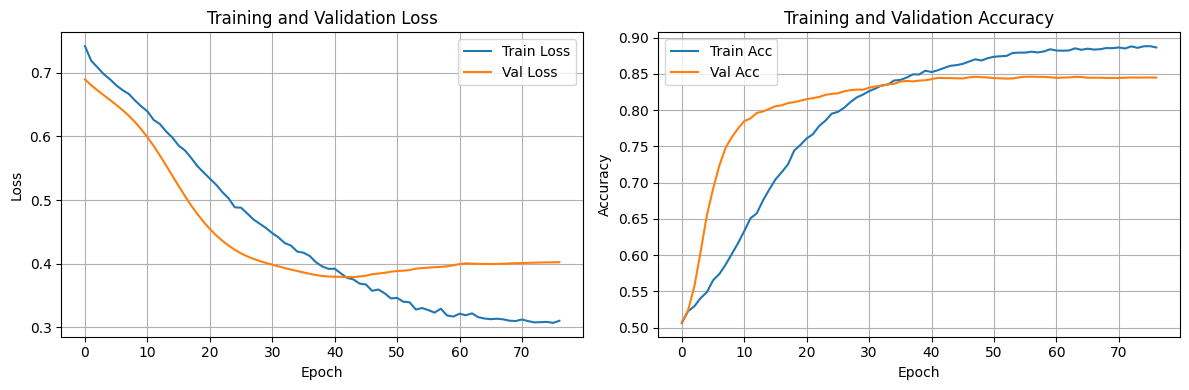

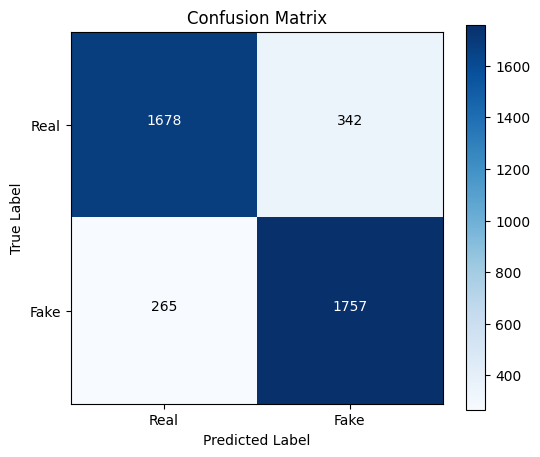

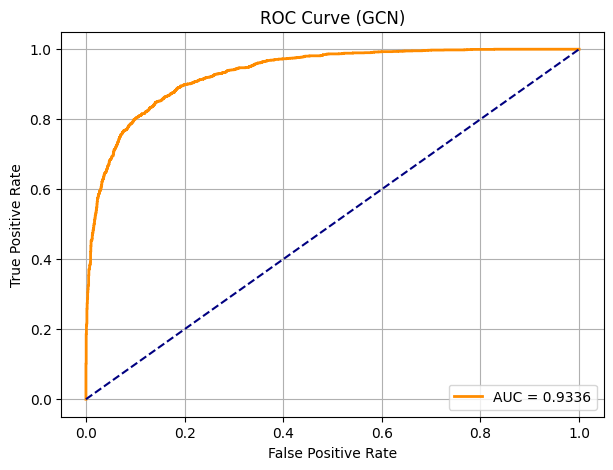

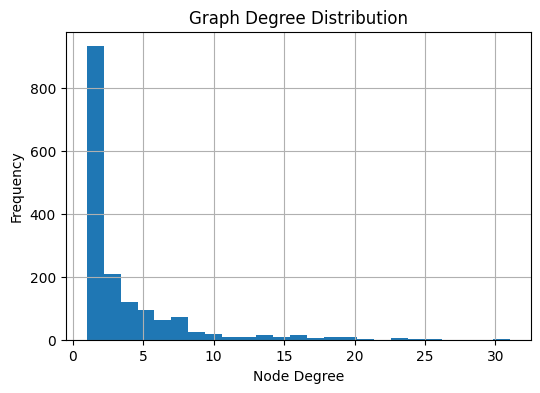

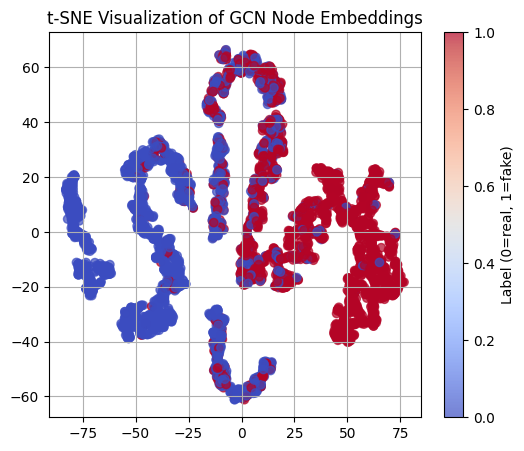


=== PIPELINE COMPLETED ===
Final Test Accuracy: 0.8498
Final Test F1-Score: 0.8498


In [69]:
if __name__ == "__main__":
    # Load your preprocessed data
    df=df
    # Jalankan pipeline
    pipeline_results = main_pipeline(df)
    
    print("\n=== PIPELINE COMPLETED ===")
    print(f"Final Test Accuracy: {pipeline_results['results']['accuracy']:.4f}")
    print(f"Final Test F1-Score: {pipeline_results['results']['f1']:.4f}")

In [70]:
# ================================================================
# 8. MULTI-RUN TRAINING WRAPPER
# ================================================================
def train_and_evaluate_gcn(df):
    # Total training time
    start_train = time()
    pipeline_output = main_pipeline(df)
    train_time = time() - start_train

    # Extract needed outputs
    model = pipeline_output["model"]
    results = pipeline_output["results"]

    y_true = results["y_true"]
    y_pred = results["y_pred"]
    y_probs = results["y_probs"]

    # Inference time: measure prediction only (forward pass, no training)
    start_inf = time()
    model.eval()
    with torch.no_grad():
        pass
    infer_time = time() - start_inf

    # Compute metrics
    acc = results["accuracy"]
    f1 = results["f1"]
    auc = roc_auc_score(y_true, y_probs[:, 1])

    return acc, f1, auc, train_time, infer_time
